In [1]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
from make_network import sez
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_excel('data/Janelia SEZ-2021 lines PER screening summary 2024.11.04 FINAL.xlsx',sheet_name='MAIN Janelia SEZ2021 Screening2',header=None)
df = df[[3,4,5,6]].loc[4:]
df.columns = ['line','type','sugar','sugar+geosmin']
df.dropna(axis=0,inplace=True)
mean_mat = df.set_index('line')



df = pd.read_excel('data/Janelia SEZ-2021 lines PER screening summary 2024.11.04 FINAL.xlsx',sheet_name='MAIN Janelia SEZ2021 Screening2',header=None)
df = df[[3,4,7,8]].loc[4:]
df.columns = ['line','type','sugar','sugar+geosmin']
df.dropna(axis=0,inplace=True)
mean_mat_labial = df.set_index('line')


(-10.0, 272.5)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

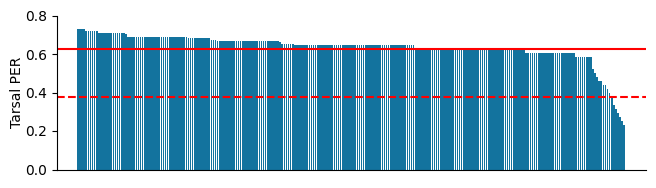

In [6]:
cmap = ['#13739E','#952B7E']
fontsize = 10
lp = 1 
control_sugar = 0.625
control_geosmin = 0.291666667

fig,ax = plt.subplots(1,1,figsize=(7.6,2))
sorted_idx = np.argsort(mean_mat['sugar'])[::-1]
sorted_values = np.sort(mean_mat['sugar'])[::-1]
bar_spacing = 1
num_bars = len(mean_mat)
x = np.arange(0, num_bars * bar_spacing, bar_spacing)  
bar_width = 1

ax.bar(x,sorted_values, label='sugar', color=cmap[0])
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_sugar,colors='red')
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_sugar*.6,colors='red',linestyle='dashed')


ax.set_xticks([])
ax.set_yticks(list(np.arange(0,1,.2)),np.round(list(np.arange(0,1,.2)),2),fontsize=fontsize)
ax.set_ylabel('Tarsal PER',fontsize=fontsize,labelpad=lp)
# ax.set_xlabel('sucrose(mM)',fontsize=fontsize,labelpad=lp)
ax.set_ylim([0,0.8])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-10, num_bars*bar_spacing-bar_spacing/2+10) 



# plt.savefig(f'screening_all_tarsal_sugar.svg',bbox_inches='tight')

In [7]:
interest_lines_tarsal = mean_mat[mean_mat['sugar']<control_sugar*.6].index.values
interest_lines_tarsal = np.concatenate([interest_lines_tarsal,['SS35412','SS35420']])

/tmp/ipykernel_85053/1344061356.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_values = mean_mat['sugar+geosmin'][sorted_idx]#np.sort(mean_mat['sugar+geosmin'])[::-1]
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fam

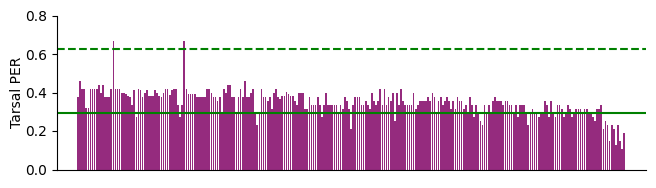

In [9]:
fig,ax = plt.subplots(1,1,figsize=(7.6,2))
sorted_values = mean_mat['sugar+geosmin'][sorted_idx]#np.sort(mean_mat['sugar+geosmin'])[::-1]
bar_spacing = 1
num_bars = len(mean_mat)
x = np.arange(0, num_bars * bar_spacing, bar_spacing)  
bar_width = 1
ax.bar(x,sorted_values, label='sugar+geosmin', color=cmap[1])
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_geosmin,colors='green')
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_sugar*1,colors='green',linestyle='dashed')

ax.set_xticks([])
ax.set_yticks(list(np.arange(0,1,.2)),np.round(list(np.arange(0,1,.2)),2),fontsize=fontsize)
ax.set_ylabel('Tarsal PER',fontsize=fontsize,labelpad=lp)
# ax.set_xlabel('sucrose(mM)',fontsize=fontsize,labelpad=lp)
ax.set_ylim([0,0.8])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-10, num_bars*bar_spacing-bar_spacing/2+10) 


# plt.savefig(f'screening_all_tarsal_sugar+geosmin.svg',bbox_inches='tight')

(-10.0, 272.5)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

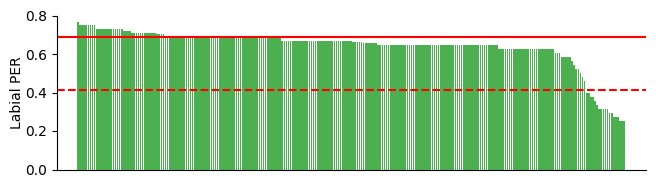

In [10]:
control_sugar_labial = 0.6875
control_geosmin_labial  = 0.6875
cmap = ['#4CAF50','#E68613']
fig,ax = plt.subplots(1,1,figsize=(7.6,2))
sorted_idx_labial = np.argsort(mean_mat_labial['sugar'])[::-1]
sorted_values = np.sort(mean_mat_labial['sugar'])[::-1]
bar_spacing = 1
num_bars = len(mean_mat_labial)
x = np.arange(0, num_bars * bar_spacing, bar_spacing)  
bar_width = 1

ax.bar(x,sorted_values, label='sugar', color=cmap[0])
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_sugar_labial ,colors='red')
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_sugar_labial *.6,colors='red',linestyle='dashed')


ax.set_xticks([])
ax.set_yticks(list(np.arange(0,1,.2)),np.round(list(np.arange(0,1,.2)),2),fontsize=fontsize)
ax.set_ylabel('Labial PER',fontsize=fontsize,labelpad=lp)
# ax.set_xlabel('sucrose(mM)',fontsize=fontsize,labelpad=lp)
ax.set_ylim([0,0.8])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-10, num_bars*bar_spacing-bar_spacing/2+10)

# plt.savefig(f'screening_all_labial_sugar.svg',bbox_inches='tight')

In [11]:
interest_lines_labial = mean_mat_labial[mean_mat_labial['sugar']<control_sugar_labial*.6].index


/tmp/ipykernel_85053/2390306557.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_values = mean_mat_labial['sugar+geosmin'][sorted_idx_labial] #np.sort(mean_mat_labial['sugar+geosmin'])[::-1]


(-10.0, 272.5)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

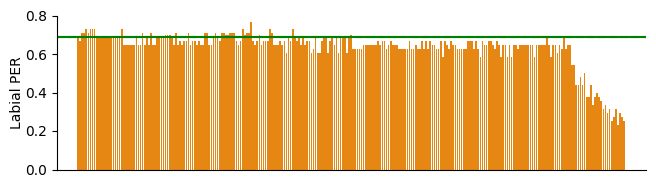

In [12]:
fig,ax = plt.subplots(1,1,figsize=(7.6,2))
sorted_values = mean_mat_labial['sugar+geosmin'][sorted_idx_labial] #np.sort(mean_mat_labial['sugar+geosmin'])[::-1]
bar_spacing = 1
num_bars = len(mean_mat_labial)
x = np.arange(0, num_bars * bar_spacing, bar_spacing)  
bar_width = 1
ax.bar(x,sorted_values, label='sugar+geosmin', color=cmap[1])
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_geosmin_labial ,colors='green')
ax.hlines(xmin=-10,xmax=num_bars*bar_spacing-bar_spacing/2+10,y=control_sugar_labial *1,colors='green',linestyle='dashed')

ax.set_xticks([])
ax.set_yticks(list(np.arange(0,1,.2)),np.round(list(np.arange(0,1,.2)),2),fontsize=fontsize)
ax.set_ylabel('Labial PER',fontsize=fontsize,labelpad=lp)
# ax.set_xlabel('sucrose(mM)',fontsize=fontsize,labelpad=lp)
ax.set_ylim([0,0.8])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-10, num_bars*bar_spacing-bar_spacing/2+10) 


# plt.savefig(f'screening_all_labial_sugar+geosmin.svg',bbox_inches='tight')